In [3]:
# Import Google Earth Engine Library

import ee

ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='california2025')

# ee.Authenticate()
# ee.Initialize()

c:\Users\hyon0\miniconda3\envs\hhpark\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [5]:
# Image Filter Parameter Set

california_aoi = ee.Geometry.Rectangle([-118.71446343005898, 33.99939074406538, -118.48855705798867, 34.16090634156051])

START_DATE = '2024-12-01'
END_DATE = '2026-01-01'
CLOUD_FILTER = 10

In [6]:
# Load Sentinel-2 L2A and CLD

L2A_dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(START_DATE, END_DATE)
    .filterBounds(california_aoi)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER))
)

CLD_dataset = (
    ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(california_aoi)
)

In [7]:
# resampling

def resample_to_B2(image):
    base_band = image.select('B2')
    resampled_image = image.resample('bilinear').reproject(
        crs=base_band.projection().crs(),
        scale=base_band.projection().nominalScale()
    )
    return resampled_image

resampled_L2A_dataset = L2A_dataset.map(resample_to_B2)

In [8]:
# Match Date between Sentinel-2 and CLD

join = ee.Join.saveFirst('cloud_mask')

condition = ee.Filter.equals(
    leftField='system:index',
    rightField='system:index'
)

L2A_with_CLD = join.apply(resampled_L2A_dataset, CLD_dataset, condition)

In [9]:
# Create NDVI Band and Clip by AOI

def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndvi_clipped = ndvi.clip(california_aoi)
    return ndvi_clipped

def calculate_nbr(image):
    nbr = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    nbr_clipped = nbr.clip(california_aoi)
    return nbr_clipped

def clip_cloud_mask(image):
    cloud_mask = ee.Image(image.get('cloud_mask')).select('probability')
    return cloud_mask.clip(california_aoi)


In [10]:
# Create Collection

ndvi_collection = ee.ImageCollection(L2A_with_CLD).map(calculate_ndvi)

nbr_collection = ee.ImageCollection(L2A_with_CLD).map(calculate_nbr)

cloud_mask_collection = ee.ImageCollection(L2A_with_CLD).map(clip_cloud_mask)

In [11]:
print("NDVI image count:", ndvi_collection.size().getInfo())
print("NBR image count:", nbr_collection.size().getInfo())
print("Cloud mask image count:", cloud_mask_collection.size().getInfo())

NDVI image count: 26
NBR image count: 26
Cloud mask image count: 26


In [12]:
ndvi_list = ndvi_collection.toList(ndvi_collection.size())
nbr_list = nbr_collection.toList(nbr_collection.size())
cloud_mask_list = cloud_mask_collection.toList(cloud_mask_collection.size())

In [11]:
# Export NDVI, NBR, and Cloud Probability Images to Google Drive

count = ndvi_collection.size().getInfo()

for i in range(count):
    ndvi_image = ee.Image(ndvi_list.get(i))
    nbr_image = ee.Image(nbr_list.get(i))
    cloud_image = ee.Image(cloud_mask_list.get(i))

    image_id = ndvi_list.get(i).getInfo()['properties']['system:index'][:8]

    task_ndvi = ee.batch.Export.image.toDrive(**{
        'image': ndvi_image,
        'description': f"California_NDVI_{image_id}",
        'scale': 10,
        'region': california_aoi.getInfo()['coordinates'],
        'fileFormat': 'GeoTIFF'
    })

    task_nbr = ee.batch.Export.image.toDrive(**{
        'image': nbr_image,
        'description': f"California_NBR_{image_id}",
        'scale': 10,
        'region': california_aoi.getInfo()['coordinates'],
        'fileFormat': 'GeoTIFF'
    })

    task_cld = ee.batch.Export.image.toDrive(**{
        'image': cloud_image,
        'description': f"California_Cloud_Probability_{image_id}",
        'scale': 10,
        'region': california_aoi.getInfo()['coordinates'],
        'fileFormat': 'GeoTIFF'
    })

    task_ndvi.start()
    task_nbr.start()
    task_cld.start()

In [13]:
# Check NDVI Image Order and Date

for i in range(ndvi_collection.size().getInfo()):
    image_id = ndvi_list.get(i).getInfo()['properties']['system:index']
    print(image_id[:8])

20241218
20250102
20250112
20250221
20250303
20250308
20250318
20250404
20250407
20250507
20250514
20250616
20250623
20250706
20250805
20250822
20250830
20250909
20251001
20251004
20251009
20251029
20251123
20251128
20251208
20251228


In [14]:
# Select pre-fire NBR image
pre_fire_nbr = ee.Image(nbr_list.get(0))

# Create dNBR collection
def calculate_dnbr(post_fire_image):
    dnbr = pre_fire_nbr.subtract(post_fire_image).rename('dNBR')
    return dnbr

dnbr_collection = nbr_collection.map(calculate_dnbr)

In [15]:
dnbr_list = dnbr_collection.toList(dnbr_collection.size())

In [16]:
# Export dNBR Images to Google Drive

count = dnbr_collection.size().getInfo()

for i in range(count):
    dnbr_image = ee.Image(dnbr_list.get(i))

    image_id = nbr_list.get(i).getInfo()['properties']['system:index'][:8]

    task_dnbr = ee.batch.Export.image.toDrive(**{
        'image': dnbr_image,
        'description': f"California_dNBR_{image_id}",
        'scale': 10,
        'region': california_aoi.getInfo()['coordinates'],
        'fileFormat': 'GeoTIFF'
    })

    task_dnbr.start()

In [18]:
pip install pandas matplotlib

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -------------------------- ------------- 7.6/11.3 MB 42.7 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 39.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 4.2 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 7.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 9.2 MB/s  0:00:01
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 10.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.9 MB 12.2 MB/s eta 0:00:01
   --------------- ------------------------ 5.

In [20]:
# Create Burn Scar Mask and Time Series DataFrame

import pandas as pd
import matplotlib.pyplot as plt

# 1. Select pre-fire and early post-fire NBR
# 보통 0번이 산불 전 영상이면 그대로 사용
pre_fire_nbr = ee.Image(nbr_list.get(0))

# 산불 직후 영상 인덱스 선택
# 날짜 출력 결과 보고 2025-01 이후 첫 영상 번호로 바꿔도 됨
post_fire_nbr_for_mask = ee.Image(nbr_list.get(1))

# 2. Create initial dNBR image for burn scar mask
initial_dnbr = pre_fire_nbr.subtract(post_fire_nbr_for_mask).rename('dNBR_mask')

# 3. Create burn scar mask
# threshold는 처음엔 0.3 추천. 너무 작거나 크면 0.2~0.4로 조정
burn_mask = initial_dnbr.gt(0.3)

# 4. Calculate mean values only inside burn scar mask
data = []

count = ndvi_collection.size().getInfo()

for i in range(count):
    ndvi_image = ee.Image(ndvi_list.get(i)).updateMask(burn_mask)
    nbr_image = ee.Image(nbr_list.get(i)).updateMask(burn_mask)
    dnbr_image = ee.Image(dnbr_list.get(i)).updateMask(burn_mask)

    image_id = ndvi_list.get(i).getInfo()['properties']['system:index']
    date = image_id[:8]

    ndvi_mean = ndvi_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=california_aoi,
        scale=10,
        maxPixels=1e13
    ).get('NDVI').getInfo()

    nbr_mean = nbr_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=california_aoi,
        scale=10,
        maxPixels=1e13
    ).get('NBR').getInfo()

    dnbr_mean = dnbr_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=california_aoi,
        scale=10,
        maxPixels=1e13
    ).get('dNBR').getInfo()

    data.append({
        'date': date,
        'NDVI': ndvi_mean,
        'NBR': nbr_mean,
        'dNBR': dnbr_mean
    })

df_burn = pd.DataFrame(data)
df_burn['date'] = pd.to_datetime(df_burn['date'], format='%Y%m%d')
df_burn = df_burn.sort_values('date')

df_burn

,date,NDVI,NBR,dNBR
0,2024-12-18,0.201949,0.241825,0.000000
1,2025-01-02,-0.364571,-0.314283,0.555767
2,2025-01-12,-0.109046,-0.032033,0.274098
3,2025-02-21,0.026457,0.068982,0.173043
4,2025-03-03,-0.041672,0.140857,0.100969
5,2025-03-08,-0.020181,0.166495,0.075330
6,2025-03-18,0.007875,0.174219,0.067606
7,2025-04-04,0.077092,0.163759,0.078066
8,2025-04-07,0.013819,0.262746,-0.020921
9,2025-05-07,0.036309,0.133533,0.108360


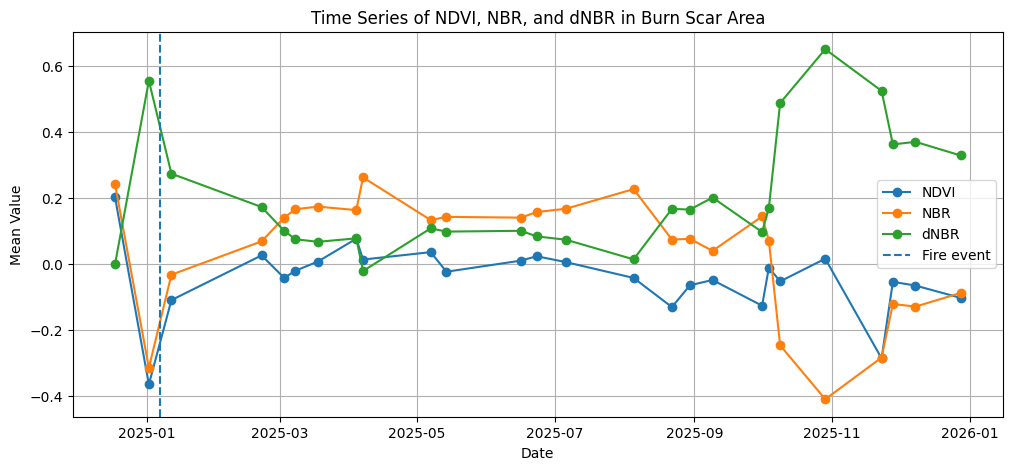

In [21]:
# Plot Burn Scar Time Series

plt.figure(figsize=(12, 5))

plt.plot(df_burn['date'], df_burn['NDVI'], marker='o', label='NDVI')
plt.plot(df_burn['date'], df_burn['NBR'], marker='o', label='NBR')
plt.plot(df_burn['date'], df_burn['dNBR'], marker='o', label='dNBR')

plt.axvline(pd.to_datetime('2025-01-07'), linestyle='--', label='Fire event')

plt.title('Time Series of NDVI, NBR, and dNBR in Burn Scar Area')
plt.xlabel('Date')
plt.ylabel('Mean Value')
plt.legend()
plt.grid(True)
plt.show()